In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Downloa
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Load dataset
data = pd.read_csv("fake_reviews.csv")

# Clean column names
data.columns = data.columns.str.strip()
print("Columns:", data.columns)

# Setup tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = nltk.word_tokenize(text)
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

# ✅ USE THE CORRECT COLUMN NAME: text_
data['clean_review'] = data['text_'].apply(clean_text)

# Show output
data.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Columns: Index(['category', 'rating', 'label', 'text_'], dtype='object')


,category,rating,label,text_,clean_review
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",love well made sturdi comfort love itveri pretti
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",love great upgrad origin ive mine coupl year
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,pillow save back love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",miss inform use great product price
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,nice set good qualiti set two month


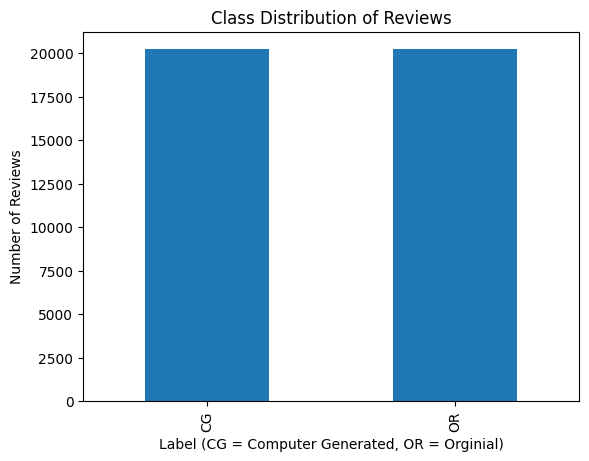

In [4]:
import matplotlib.pyplot as plt

data['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution of Reviews")
plt.xlabel("Label (CG = Computer Generated, OR = Orginial)")
plt.ylabel("Number of Reviews")
plt.show()



The review text is converted to lowercase and cleaned by removing special characters and stopwords. Tokenization and stemming are applied to reduce words to their root form. The processed data is stored in a new column named clean_review for further analysis.


In [5]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
print(data.columns)

Index(['category', 'rating', 'label', 'text_', 'clean_review'], dtype='object')


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numerical features
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(data['clean_review'])
y = data['label']

print(X.shape)

(40432, 5000)


In [34]:
# create review length feature
df['review_length'] = df['text_'].str.len()

# histogram data
lengths = df['review_length']
counts, bins = np.histogram(lengths, bins=30)

print(counts)

[11767  9354  5045  3164  2133  1624  1195  1018   830   725   620   576
   500   458   371   261   205   207   171   108    58    25    11     0
     2     0     0     0     3     1]


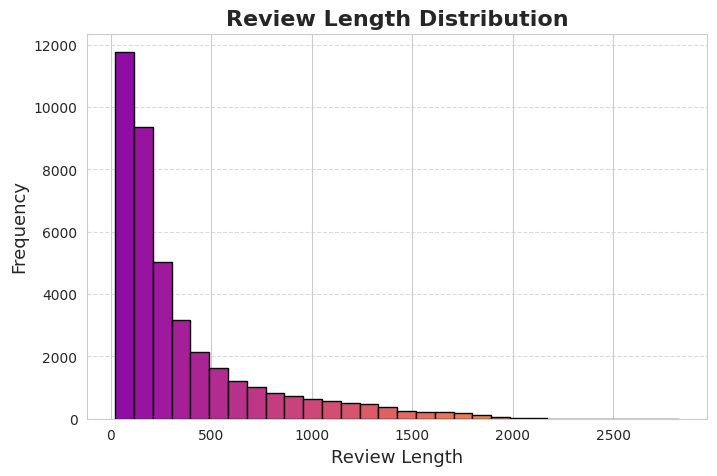

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



# Create review length column
df['review_length'] = df['text_'].str.len()

# Bright and clean style
sns.set_style("whitegrid")

# histogram data
lengths = df['review_length']
counts, bins = np.histogram(lengths, bins=30)

# Bright colormap
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(counts)))

plt.figure(figsize=(8,5))
plt.bar(bins[:-1], counts, width=np.diff(bins), color=colors, edgecolor='black', align='edge')

# Titles and labels
plt.title("Review Length Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Review Length", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [21]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (32345, 5000)
Testing samples: (8087, 5000)


In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8451836280450105


In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8650921231606282


In [24]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.886608136515395


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8428341783108693


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

# Assuming SVM performed best
svm_pred = svm.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, svm_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, svm_pred))

Classification Report:

              precision    recall  f1-score   support

          CG       0.90      0.87      0.88      4016
          OR       0.87      0.90      0.89      4071

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087

Confusion Matrix:

[[3489  527]
 [ 390 3681]]


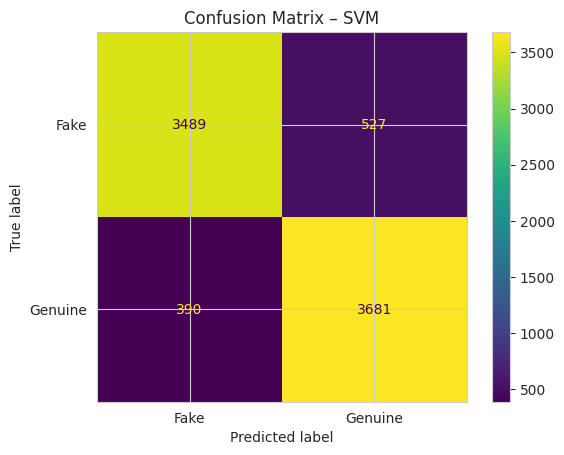

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, svm_pred, display_labels=["Fake", "Genuine"]
)
plt.title("Confusion Matrix – SVM")
plt.show()


In [28]:
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append([name, acc])

comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
comparison_df

,Model,Accuracy
0,Naive Bayes,0.845184
1,Logistic Regression,0.865092
2,SVM,0.886608
3,Random Forest,0.842834


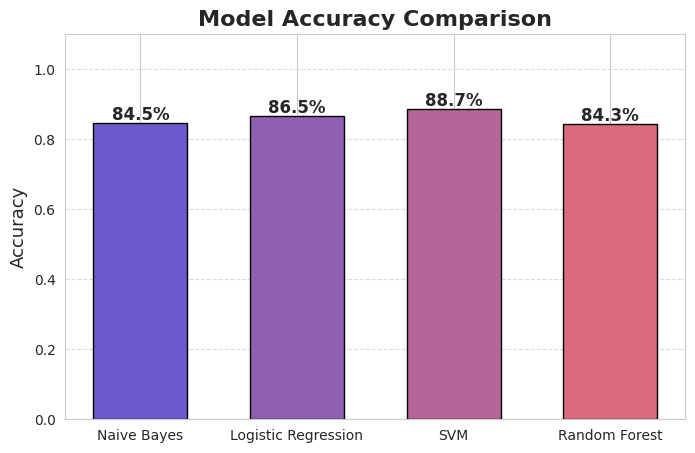

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from matplotlib.colors import LinearSegmentedColormap

# Models and accuracies
models = ['Naive Bayes', 'Logistic Regression', 'SVM', 'Random Forest']
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, rf_pred)  # replace with your Random Forest predictions
]


cmap = LinearSegmentedColormap.from_list("purple_pink", ["#6A5ACD", "#FF6F61"])
colors = [cmap(i/len(models)) for i in range(len(models))]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.6)

# Add accuracy labels on top
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc*100:.1f}%",
             ha='center', fontsize=12, fontweight='bold')

plt.ylim(0,1.1)
plt.title("Model Accuracy Comparison", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [38]:
def predict_review(review):
    review = clean_text(review)
    vec = tfidf.transform([review])
    prediction = model.predict(vec)
    return prediction[0]

print(predict_review("This product is amazing!"))

CG


In [36]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

params = {'C':[0.1,1,10]}

grid = GridSearchCV(
    LinearSVC(),
    params,
    cv=5,
    verbose=2
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_


Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ..............................................C=0.1; total time=   0.2s
[CV] END ..............................................C=0.1; total time=   0.2s
[CV] END ..............................................C=0.1; total time=   0.2s
[CV] END ..............................................C=0.1; total time=   0.2s
[CV] END ..............................................C=0.1; total time=   0.2s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.4s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ................................................C=1; total time=   0.3s
[CV] END ...............................................C=10; total time=   0.5s
[CV] END ........................................

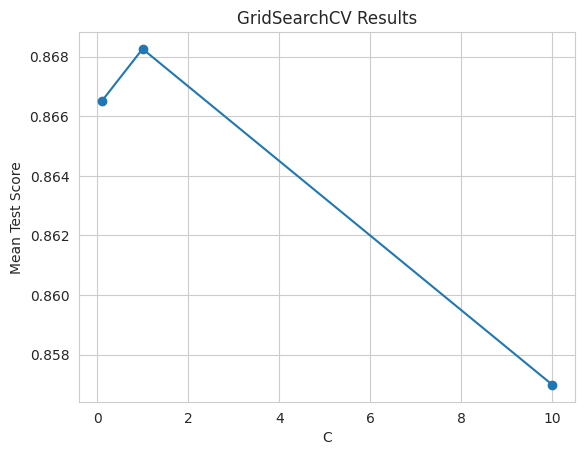

In [37]:
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.plot(results['param_C'], results['mean_test_score'], marker='o')
plt.xlabel("C")
plt.ylabel("Mean Test Score")
plt.title("GridSearchCV Results")
plt.show()


